# Reuse one geometry across registered tracers

        ## Author

        [Rafael S. de Souza](https://rafaelsdesouza.com.br/)

        ## Learning goals

        - separate geometry from measurement
- compare profiles without redefining radial position

        ## Keywords

        registered tracers, geometry reuse, radial profiles

        ## Summary

        Measure brightness, colour, and velocity-like fields on one immutable geometry.

        ## Resources

        - [Documentation](https://rafaelsdesouza.com.br/multiradial/docs/)
        - [Source](https://github.com/RafaelSdeSouza/multiradial)
        - Paper/preprint: bibliographic link pending
        - [Citation metadata](https://github.com/RafaelSdeSouza/multiradial/blob/main/CITATION.cff)

        Execute this notebook from a local checkout. A Colab installation link
        will be added only after the first immutable release tag exists.

In [1]:
from pathlib import Path
import sys
source = Path("src") if Path("src/radialpaths").exists() else Path("../src")
if str(source.resolve()) not in sys.path:
    sys.path.insert(0, str(source.resolve()))

import matplotlib.pyplot as plt
import numpy as np
from radialpaths import build_geometry, radial_profile

plt.rcParams.update({"font.size": 10, "axes.titlesize": 11, "axes.linewidth": 0.8})

In [2]:
yy, xx = np.indices((91, 121), dtype=float)
support = ((xx - 55) / 47) ** 2 + ((yy - 45) / 31) ** 2 <= 1
support |= ((xx >= 48) & (xx <= 106) & (np.abs(yy - (45 + 0.25 * (xx - 48))) <= 7))
centres = [(43, 28), (54, 81)]
geometry = build_geometry(support, centres)

brightness = np.full(support.shape, np.nan)
colour = np.full(support.shape, np.nan)
velocity = np.full(support.shape, np.nan)
brightness[support] = np.exp(-geometry.centre_distance[support] / 13)
colour[support] = 0.2 + 0.65 * xx[support] / support.shape[1]
velocity[support] = -90 + 180 * xx[support] / support.shape[1]

measurements = {
    "brightness": radial_profile(brightness, geometry, coordinate="rho_X"),
    "colour": radial_profile(colour, geometry, coordinate="rho_X"),
    "velocity": radial_profile(velocity, geometry, coordinate="rho_X"),
}

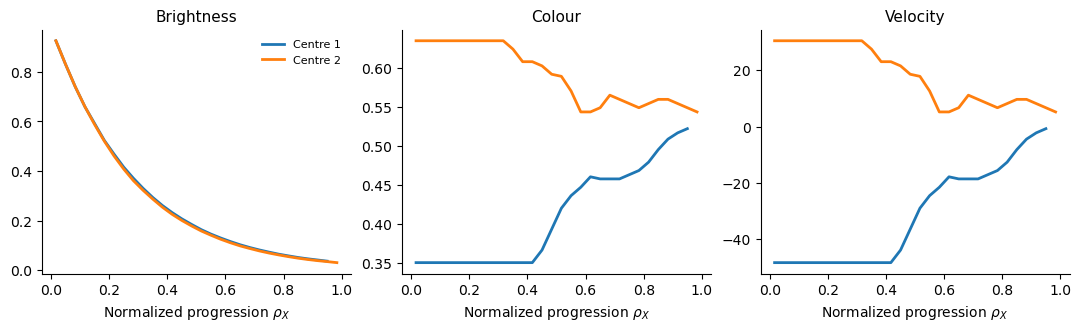

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(10.7, 3.2), constrained_layout=True)
for ax, (name, profile) in zip(axes, measurements.items()):
    for centre_index, values in enumerate(profile.median):
        ax.plot(profile.radius, values, lw=2, label=f"Centre {centre_index + 1}")
    ax.set(xlabel=r"Normalized progression $\rho_X$", title=name.capitalize())
    ax.spines[["top", "right"]].set_visible(False)
axes[0].legend(frameon=False, fontsize=8)
plt.show()

All three profile calls use the same support, centre assignment,
graph distances, and coordinate arrays. Only the registered
pixel values passed to the estimator differ.